SPATIAL PATTERN VISUALIZATION GENERATOR

Grid specifications:
  - RNA: Hexagonal Visium-like spots, 55µm diameter, 100µm spacing
  - MSI: Cartesian grid, 60x60µm squares

MSI directory: /home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/msi/
RNA directory: /home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/rna/
Output directory: /home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/pattern_visualizations
Ground truth patterns: 50
Noise patterns: 500
Total images to generate: 550

----------------------------------------------------------------------

[1/2] Generating Ground Truth Pattern Visualizations...
----------------------------------------------------------------------


GT Patterns:   0%|          | 0/50 [00:00<?, ?pattern/s]

/tmp/ipykernel_1415590/242642238.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
GT Patterns:   2%|▏         | 1/50 [00:10<08:40, 10.62s/pattern]/tmp/ipykernel_1415590/242642238.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
GT Patterns:   4%|▍         | 2/50 [00:21<08:29, 10.62s/pattern]/tmp/ipykernel_1415590/242642238.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
GT Patterns:   6%|▌         | 3/50 [00:31<08:19, 10.63s/pattern]/tmp/ipykernel_1415590/242642238.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
GT P


[2/2] Generating Noise Pattern Visualizations...
----------------------------------------------------------------------


Noise Patterns:   0%|          | 0/500 [00:00<?, ?pattern/s]/tmp/ipykernel_1415590/242642238.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
Noise Patterns:   0%|          | 1/500 [00:05<43:57,  5.29s/pattern]/tmp/ipykernel_1415590/242642238.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
Noise Patterns:   0%|          | 2/500 [00:07<29:17,  3.53s/pattern]/tmp/ipykernel_1415590/242642238.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
Noise Patterns:   1%|          | 3/500 [00:09<24:32,  2.96s/pattern]/tmp/ipykernel_1415590/242642238.py:293: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results

KeyboardInterrupt: 

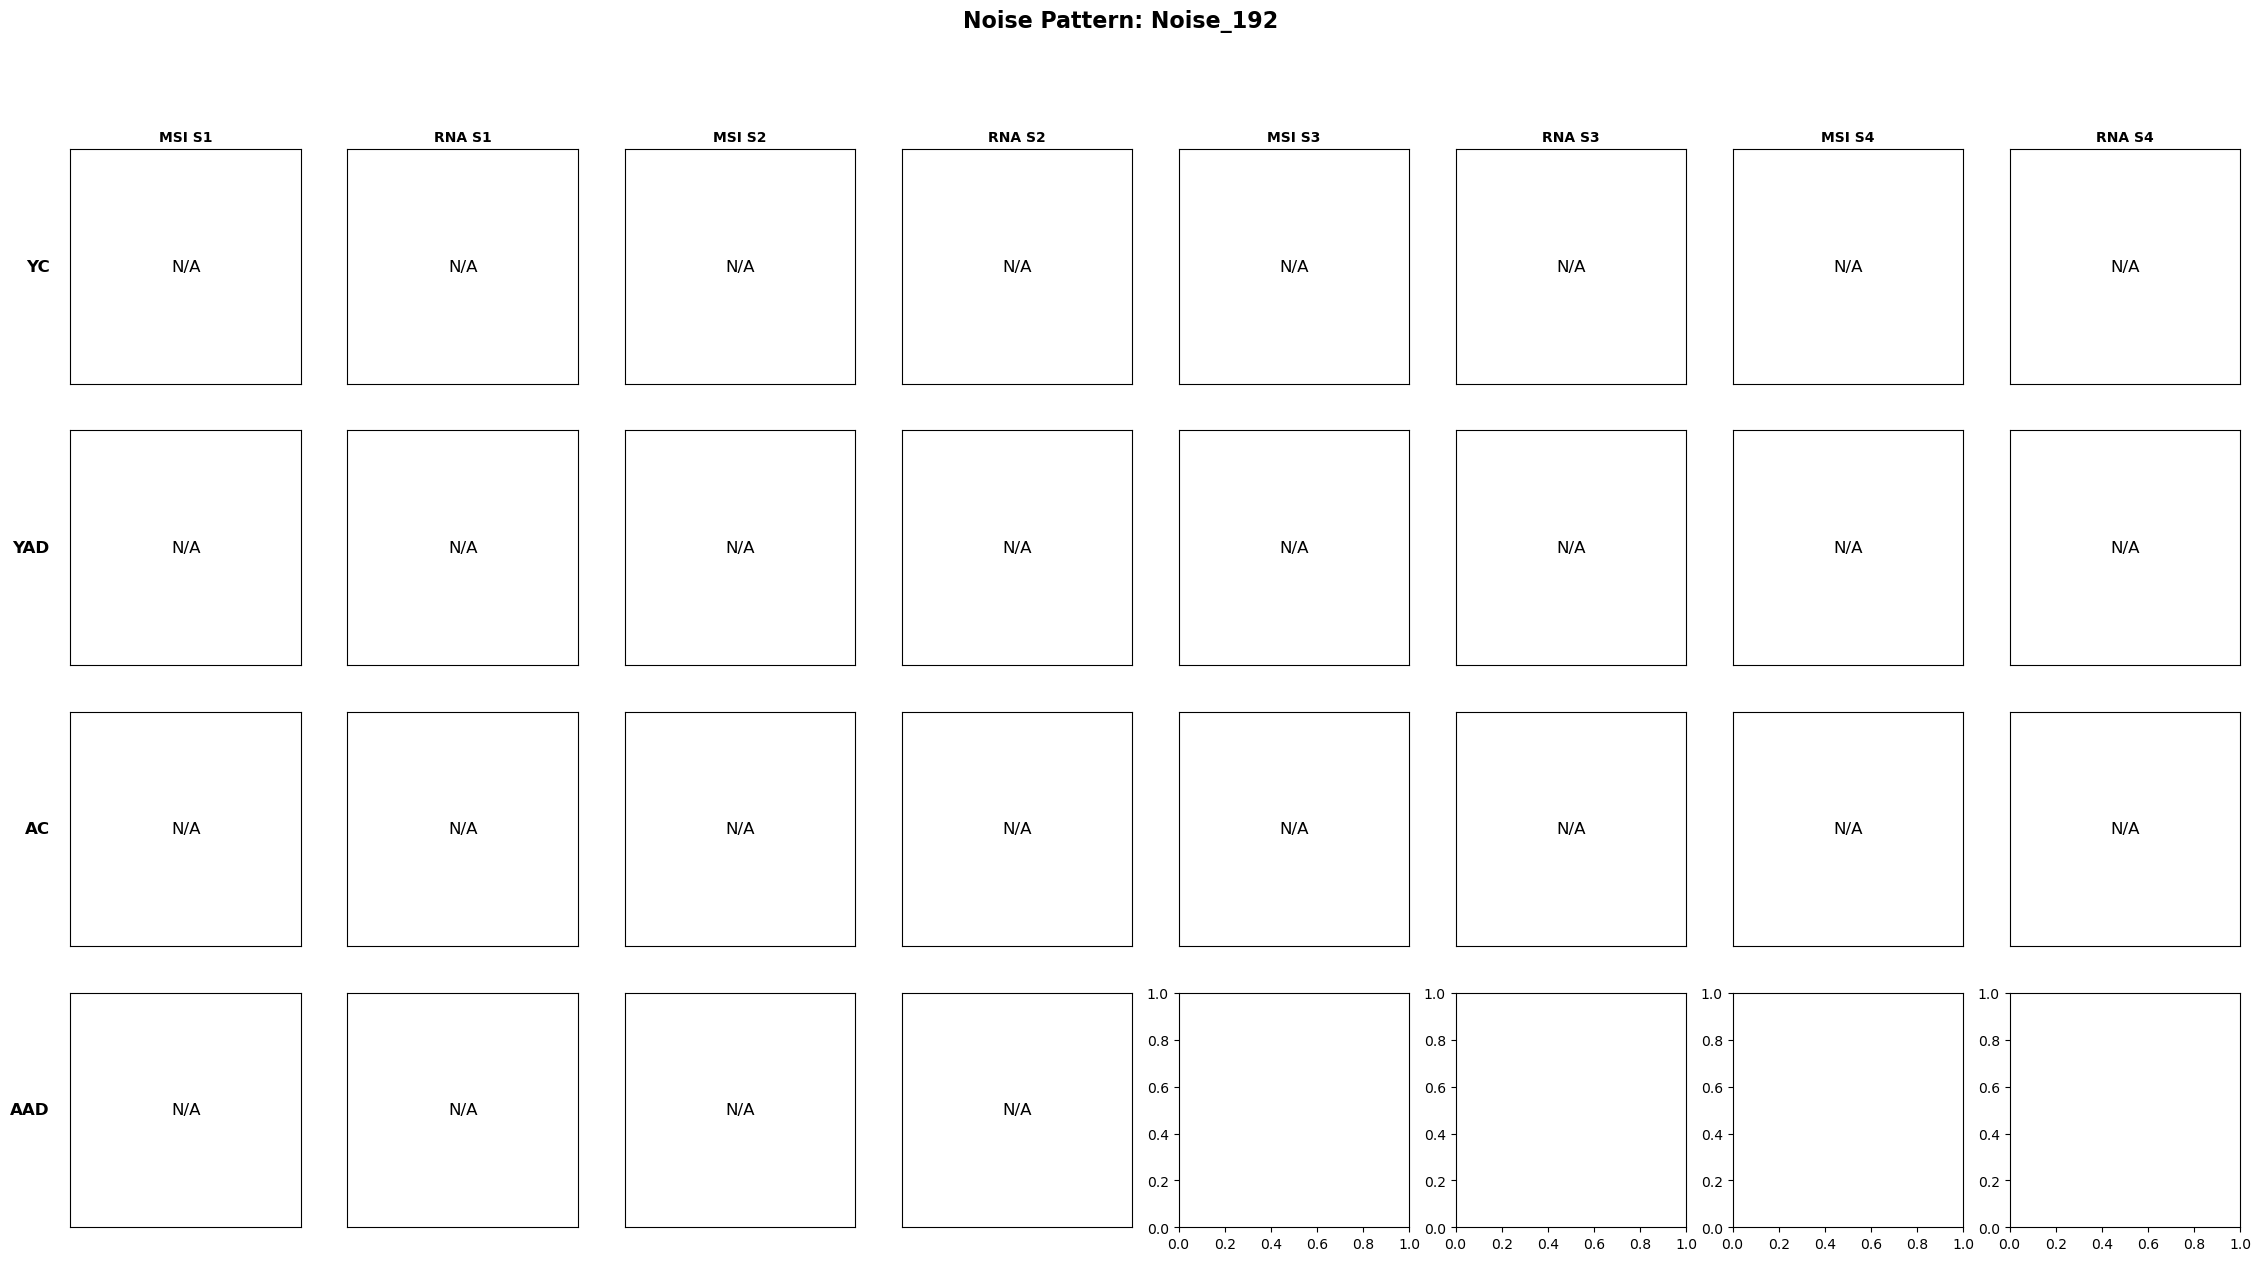

In [2]:
"""
Visualize all spatial patterns (GT + Noise) across all samples and modalities.

For each pattern, generates a composite image with:
- 4 rows (groups: YC, YAD, AC, AAD)
- 8 columns (4 MSI samples + 4 RNA samples per group)

Grid formats:
- RNA: Hexagonal Visium-like spots (55µm diameter, 100µm center-to-center)
- MSI: Cartesian grid (60µm x 60µm squares)

Total: 550 images (50 GT patterns + 500 noise patterns)
"""

import os
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle, Rectangle
from tqdm import tqdm

# =============================================================================
# CONFIGURATION
# =============================================================================
MSI_INPUT_FOLDER = "/home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/msi/"
RNA_INPUT_FOLDER = "/home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/rna/"
OUTPUT_DIR = "/home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/pattern_visualizations"

# Aliases for compatibility
MSI_DIR = MSI_INPUT_FOLDER
RNA_DIR = RNA_INPUT_FOLDER

GROUPS = ["YC", "YAD", "AC", "AAD"]
SAMPLES_PER_GROUP = 4

# Grid specifications
RNA_SPOT_DIAMETER = 55  # Visium spot diameter in micrometers
RNA_SPOT_SPACING = 100  # Center-to-center distance
MSI_PIXEL_SIZE = 60     # MSI square size in micrometers

FIGSIZE = (28, 14)  # Figure size in inches
DPI = 150
VMAX_PERCENTILE = 100  # Percentile for color scaling

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "gt_patterns"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "noise_patterns"), exist_ok=True)


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def load_sample_data(group, sample_idx):
    """Load MSI and RNA data for a specific sample."""
    # Load MSI
    msi_path = os.path.join(MSI_DIR, f"halfbrain_{group.lower()}_{sample_idx}_filtered_common.h5ad")
    adata_msi = ad.read_h5ad(msi_path)
    
    # Load RNA
    rna_path = os.path.join(RNA_DIR, f"{group}_{sample_idx}.h5ad")
    adata_rna = ad.read_h5ad(rna_path)
    
    return adata_msi, adata_rna


def get_spatial_coords(adata):
    """Extract spatial coordinates from AnnData object."""
    x = adata.obs['x_um'].values
    y = adata.obs['y_um'].values
    return x, y


def plot_msi_cartesian(ax, x, y, values, pixel_size=60, cmap='viridis', norm=None):
    """
    Plot MSI data as a Cartesian grid of squares.
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to plot on
    x, y : arrays
        Spatial coordinates (centers of squares) in micrometers
    values : array
        Feature values at each coordinate
    pixel_size : float
        Size of each square in micrometers
    cmap : str
        Colormap name
    norm : Normalize
        Normalization for colormap
    """
    # Create rectangles for each pixel
    rectangles = []
    colors = []
    
    half_size = pixel_size / 2
    
    for xi, yi, val in zip(x, y, values):
        # Rectangle centered at (xi, yi)
        rect = Rectangle((xi - half_size, yi - half_size), pixel_size, pixel_size)
        rectangles.append(rect)
        colors.append(val)
    
    # Create collection
    pc = PatchCollection(rectangles, cmap=cmap, norm=norm, edgecolors='none')
    pc.set_array(np.array(colors))
    ax.add_collection(pc)
    
    # Set axis limits
    margin = pixel_size
    ax.set_xlim(x.min() - margin, x.max() + margin)
    ax.set_ylim(y.min() - margin, y.max() + margin)
    ax.set_aspect('equal')
    
    return pc


def plot_rna_hexagonal(ax, x, y, values, spot_diameter=55, cmap='viridis', norm=None):
    """
    Plot RNA data as hexagonal Visium-like spots.
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to plot on
    x, y : arrays
        Spatial coordinates (centers of spots) in micrometers
    values : array
        Feature values at each coordinate
    spot_diameter : float
        Diameter of each spot in micrometers
    cmap : str
        Colormap name
    norm : Normalize
        Normalization for colormap
    """
    # Create circles for each spot (Visium spots are circular)
    circles = []
    colors = []
    
    radius = spot_diameter / 2
    
    for xi, yi, val in zip(x, y, values):
        circle = Circle((xi, yi), radius)
        circles.append(circle)
        colors.append(val)
    
    # Create collection
    pc = PatchCollection(circles, cmap=cmap, norm=norm, edgecolors='none')
    pc.set_array(np.array(colors))
    ax.add_collection(pc)
    
    # Set axis limits
    margin = spot_diameter
    ax.set_xlim(x.min() - margin, x.max() + margin)
    ax.set_ylim(y.min() - margin, y.max() + margin)
    ax.set_aspect('equal')
    
    return pc


def plot_pattern_composite(pattern_name, pattern_type='gt', save=True):
    """
    Create composite visualization for a single pattern across all samples.
    
    Parameters:
    -----------
    pattern_name : str
        Name of the pattern (e.g., 'Gradient_X' for GT or 'Noise_0' for noise)
    pattern_type : str
        'gt' for ground truth patterns, 'noise' for noise patterns
    save : bool
        Whether to save the figure
    """
    # Determine feature names
    if pattern_type == 'gt':
        msi_feature = f"MZ_{pattern_name}"
        rna_feature = f"Gene_{pattern_name}"
        title = f"Ground Truth Pattern: {pattern_name}"
        output_subdir = "gt_patterns"
    else:
        idx = int(pattern_name.split('_')[1])
        msi_feature = f"MZ_Noise_{idx}"
        rna_feature = f"Gene_Noise_{idx}"
        title = f"Noise Pattern: {pattern_name}"
        output_subdir = "noise_patterns"
    
    # Create figure with subplots
    fig, axes = plt.subplots(4, 8, figsize=FIGSIZE)
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    
    # Track global min/max for consistent colormap
    all_values = []
    
    # First pass: collect all values for normalization
    for g_idx, group in enumerate(GROUPS):
        for s_idx in range(1, SAMPLES_PER_GROUP + 1):
            try:
                adata_msi, adata_rna = load_sample_data(group, s_idx)
                
                # MSI values
                if msi_feature in adata_msi.var_names:
                    msi_vals = adata_msi[:, msi_feature].X.flatten()
                    all_values.extend(msi_vals)
                
                # RNA values
                if rna_feature in adata_rna.var_names:
                    rna_vals = adata_rna[:, rna_feature].X.flatten()
                    all_values.extend(rna_vals)
            except Exception as e:
                print(f"Warning: Could not load {group}_{s_idx}: {e}")
    
    # Calculate normalization
    if len(all_values) > 0:
        vmin = np.nanpercentile(all_values, 1)
        vmax = np.nanpercentile(all_values, VMAX_PERCENTILE)
    else:
        vmin, vmax = 0, 1
    
    norm = Normalize(vmin=vmin, vmax=vmax)
    
    # Second pass: plot all panels
    for g_idx, group in enumerate(GROUPS):
        for s_idx in range(1, SAMPLES_PER_GROUP + 1):
            try:
                adata_msi, adata_rna = load_sample_data(group, s_idx)
                
                # MSI panel (columns 0, 2, 4, 6)
                msi_col = (s_idx - 1) * 2
                ax_msi = axes[g_idx, msi_col]
                
                if msi_feature in adata_msi.var_names:
                    x_msi, y_msi = get_spatial_coords(adata_msi)
                    vals_msi = adata_msi[:, msi_feature].X.flatten()
                    
                    # Plot MSI as Cartesian squares
                    plot_msi_cartesian(ax_msi, x_msi, y_msi, vals_msi, 
                                       pixel_size=MSI_PIXEL_SIZE, cmap='viridis', norm=norm)
                else:
                    ax_msi.text(0.5, 0.5, 'N/A', ha='center', va='center', 
                               transform=ax_msi.transAxes, fontsize=12)
                
                ax_msi.set_xticks([])
                ax_msi.set_yticks([])
                
                # Add column header for first row
                if g_idx == 0:
                    ax_msi.set_title(f'MSI S{s_idx}', fontsize=10, fontweight='bold')
                
                # Add row label for first column
                if s_idx == 1:
                    ax_msi.set_ylabel(group, fontsize=12, fontweight='bold', rotation=0, 
                                      ha='right', va='center', labelpad=15)
                
                # RNA panel (columns 1, 3, 5, 7)
                rna_col = (s_idx - 1) * 2 + 1
                ax_rna = axes[g_idx, rna_col]
                
                if rna_feature in adata_rna.var_names:
                    x_rna, y_rna = get_spatial_coords(adata_rna)
                    vals_rna = adata_rna[:, rna_feature].X.flatten()
                    
                    # Plot RNA as hexagonal spots (circles for Visium)
                    plot_rna_hexagonal(ax_rna, x_rna, y_rna, vals_rna,
                                       spot_diameter=RNA_SPOT_DIAMETER, cmap='viridis', norm=norm)
                else:
                    ax_rna.text(0.5, 0.5, 'N/A', ha='center', va='center', 
                               transform=ax_rna.transAxes, fontsize=12)
                
                ax_rna.set_xticks([])
                ax_rna.set_yticks([])
                
                # Add column header for first row
                if g_idx == 0:
                    ax_rna.set_title(f'RNA S{s_idx}', fontsize=10, fontweight='bold')
                    
            except Exception as e:
                print(f"Warning: Error plotting {group}_{s_idx}: {e}")
                axes[g_idx, (s_idx - 1) * 2].text(0.5, 0.5, 'Error', ha='center', va='center',
                                                   transform=axes[g_idx, (s_idx - 1) * 2].transAxes)
                axes[g_idx, (s_idx - 1) * 2 + 1].text(0.5, 0.5, 'Error', ha='center', va='center',
                                                       transform=axes[g_idx, (s_idx - 1) * 2 + 1].transAxes)
    
    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), cax=cbar_ax)
    cbar.set_label('Intensity', fontsize=11)
    
    plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
    
    if save:
        output_path = os.path.join(OUTPUT_DIR, output_subdir, f"{pattern_name}.png")
        plt.savefig(output_path, dpi=DPI, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        return output_path
    else:
        plt.show()
        return None


# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    print("=" * 70)
    print("SPATIAL PATTERN VISUALIZATION GENERATOR")
    print("=" * 70)
    print("\nGrid specifications:")
    print(f"  - RNA: Hexagonal Visium-like spots, {RNA_SPOT_DIAMETER}µm diameter, {RNA_SPOT_SPACING}µm spacing")
    print(f"  - MSI: Cartesian grid, {MSI_PIXEL_SIZE}x{MSI_PIXEL_SIZE}µm squares")
    
    # List of ground truth patterns (from the data generation script)
    GT_PATTERNS = [
        # === GRADIENTS (6 patterns) ===
        "Gradient_X", "Gradient_Y", "Gradient_Diagonal_NE", "Gradient_Diagonal_NW",
        "Gradient_Radial_In", "Gradient_Radial_Out",
        
        # === WAVES & STRIPES (8 patterns) ===
        "Stripes_Vertical", "Stripes_Horizontal", "Stripes_Diagonal_45", 
        "Stripes_Diagonal_135", "Waves_Concentric", "Waves_Spiral",
        "Waves_Interference", "Waves_Ripple",
        
        # === BLOBS & SPOTS (10 patterns) ===
        "Blob_Center", "Blob_TopRight", "Blob_TopLeft", "Blob_BottomRight",
        "Blob_BottomLeft", "Spots_Grid_Dense", "Spots_Grid_Sparse",
        "Spots_Random_Large", "Spots_Triangular", "Spots_Hexagonal",
        
        # === RINGS & DONUTS (6 patterns) ===
        "Ring_Inner", "Ring_Outer", "Ring_Double", "Ring_Eccentric",
        "Ring_Elliptical", "Ring_Partial",
        
        # === GEOMETRIC PATTERNS (8 patterns) ===
        "Checkerboard_Fine", "Checkerboard_Coarse", "Quadrant_Alternating",
        "Sectors_4", "Sectors_8", "Triangle_Pattern", "Diamond_Pattern", "Honeycomb",
        
        # === COMPLEX BIOLOGICAL-LIKE (12 patterns) ===
        "Cortical_Layers", "Hotspot_Cluster", "Edge_Enhancement", "Core_Shell",
        "Branching", "Laminar_Curved", "Mosaic_Irregular", "Gradient_Sigmoid",
        "Bimodal_Distribution", "Punctate_Dense", "Periventricular", "Asymmetric_Lobe",
    ]
    
    NOISE_FEATURES = 500
    
    print(f"\nMSI directory: {MSI_DIR}")
    print(f"RNA directory: {RNA_DIR}")
    print(f"Output directory: {OUTPUT_DIR}")
    print(f"Ground truth patterns: {len(GT_PATTERNS)}")
    print(f"Noise patterns: {NOISE_FEATURES}")
    print(f"Total images to generate: {len(GT_PATTERNS) + NOISE_FEATURES}")
    print("\n" + "-" * 70)
    
    # Check if data exists
    test_msi_path = os.path.join(MSI_DIR, "halfbrain_yc_1_filtered_common.h5ad")
    if not os.path.exists(test_msi_path):
        print(f"\nERROR: Data not found at {test_msi_path}")
        print("Please run the data generation script first.")
        exit(1)
    
    # Generate GT pattern visualizations
    print("\n[1/2] Generating Ground Truth Pattern Visualizations...")
    print("-" * 70)
    
    for pattern in tqdm(GT_PATTERNS, desc="GT Patterns", unit="pattern"):
        try:
            output_path = plot_pattern_composite(pattern, pattern_type='gt', save=True)
        except Exception as e:
            print(f"  ✗ {pattern} - Error: {e}")
    
    # Generate noise pattern visualizations
    print("\n[2/2] Generating Noise Pattern Visualizations...")
    print("-" * 70)
    
    for i in tqdm(range(NOISE_FEATURES), desc="Noise Patterns", unit="pattern"):
        try:
            pattern_name = f"Noise_{i}"
            output_path = plot_pattern_composite(pattern_name, pattern_type='noise', save=True)
        except Exception as e:
            print(f"  ✗ Noise_{i} - Error: {e}")
    
    print("\n" + "=" * 70)
    print("VISUALIZATION COMPLETE!")
    print("=" * 70)
    print(f"\nOutput directory: {OUTPUT_DIR}")
    print(f"  - GT patterns: {os.path.join(OUTPUT_DIR, 'gt_patterns')}")
    print(f"  - Noise patterns: {os.path.join(OUTPUT_DIR, 'noise_patterns')}")
    print(f"\nTotal images generated: {len(GT_PATTERNS) + NOISE_FEATURES}")

In [1]:
"""
Visualize all spatial patterns (GT + Noise) across all samples and modalities.

For each pattern, generates a composite image with:
- 4 rows (groups: YC, YAD, AC, AAD)
- 8 columns (4 MSI samples + 4 RNA samples per group)

Grid formats:
- RNA: Hexagonal Visium-like spots (55µm diameter, 100µm center-to-center)
- MSI: Cartesian grid (60µm x 60µm squares)

Noise naming convention:
- MSI: MZ_Noise_{PatternName}_{VariantIdx}
- RNA: Gene_Noise_{PatternName}_{VariantIdx}
"""

import os
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle, Rectangle
from tqdm import tqdm

# =============================================================================
# CONFIGURATION
# =============================================================================
MSI_INPUT_FOLDER = "/home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/msi/"
RNA_INPUT_FOLDER = "/home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/rna/"
OUTPUT_DIR = "/home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/pattern_visualizations"

NOISE_PER_PATTERN = 10  # Number of noise variants to generate per GT pattern

# Aliases for compatibility
MSI_DIR = MSI_INPUT_FOLDER
RNA_DIR = RNA_INPUT_FOLDER

GROUPS = ["YC", "YAD", "AC", "AAD"]
SAMPLES_PER_GROUP = 4

# Grid specifications
RNA_SPOT_DIAMETER = 55  # Visium spot diameter in micrometers
RNA_SPOT_SPACING = 100  # Center-to-center distance
MSI_PIXEL_SIZE = 60     # MSI square size in micrometers

FIGSIZE = (28, 14)  # Figure size in inches
DPI = 150
VMAX_PERCENTILE = 100  # Percentile for color scaling

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "gt_patterns"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "noise_patterns"), exist_ok=True)


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def load_sample_data(group, sample_idx):
    """Load MSI and RNA data for a specific sample."""
    # Load MSI
    msi_path = os.path.join(MSI_DIR, f"halfbrain_{group.lower()}_{sample_idx}_filtered_common.h5ad")
    adata_msi = ad.read_h5ad(msi_path)
    
    # Load RNA
    rna_path = os.path.join(RNA_DIR, f"{group}_{sample_idx}.h5ad")
    adata_rna = ad.read_h5ad(rna_path)
    
    return adata_msi, adata_rna


def get_spatial_coords(adata):
    """Extract spatial coordinates from AnnData object."""
    x = adata.obs['x_um'].values
    y = adata.obs['y_um'].values
    return x, y


def plot_msi_cartesian(ax, x, y, values, pixel_size=60, cmap='viridis', norm=None):
    """
    Plot MSI data as a Cartesian grid of squares.
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to plot on
    x, y : arrays
        Spatial coordinates (centers of squares) in micrometers
    values : array
        Feature values at each coordinate
    pixel_size : float
        Size of each square in micrometers
    cmap : str
        Colormap name
    norm : Normalize
        Normalization for colormap
    """
    # Create rectangles for each pixel
    rectangles = []
    colors = []
    
    half_size = pixel_size / 2
    
    for xi, yi, val in zip(x, y, values):
        # Rectangle centered at (xi, yi)
        rect = Rectangle((xi - half_size, yi - half_size), pixel_size, pixel_size)
        rectangles.append(rect)
        colors.append(val)
    
    # Create collection
    pc = PatchCollection(rectangles, cmap=cmap, norm=norm, edgecolors='none')
    pc.set_array(np.array(colors))
    ax.add_collection(pc)
    
    # Set axis limits
    margin = pixel_size
    ax.set_xlim(x.min() - margin, x.max() + margin)
    ax.set_ylim(y.min() - margin, y.max() + margin)
    ax.set_aspect('equal')
    
    return pc


def plot_rna_hexagonal(ax, x, y, values, spot_diameter=55, cmap='viridis', norm=None):
    """
    Plot RNA data as hexagonal Visium-like spots.
    
    Parameters:
    -----------
    ax : matplotlib axis
        Axis to plot on
    x, y : arrays
        Spatial coordinates (centers of spots) in micrometers
    values : array
        Feature values at each coordinate
    spot_diameter : float
        Diameter of each spot in micrometers
    cmap : str
        Colormap name
    norm : Normalize
        Normalization for colormap
    """
    # Create circles for each spot (Visium spots are circular)
    circles = []
    colors = []
    
    radius = spot_diameter / 2
    
    for xi, yi, val in zip(x, y, values):
        circle = Circle((xi, yi), radius)
        circles.append(circle)
        colors.append(val)
    
    # Create collection
    pc = PatchCollection(circles, cmap=cmap, norm=norm, edgecolors='none')
    pc.set_array(np.array(colors))
    ax.add_collection(pc)
    
    # Set axis limits
    margin = spot_diameter
    ax.set_xlim(x.min() - margin, x.max() + margin)
    ax.set_ylim(y.min() - margin, y.max() + margin)
    ax.set_aspect('equal')
    
    return pc


def plot_pattern_composite(pattern_name, pattern_type='gt', parent_pattern=None,
                           variant_idx=None, save=True):
    """
    Create composite visualization for a single pattern across all samples.
    
    Parameters:
    -----------
    pattern_name : str
        Display name for the pattern (used in title and filename)
    pattern_type : str
        'gt' for ground truth patterns, 'noise' for noise patterns
    parent_pattern : str or None
        For noise: the parent GT pattern name (e.g., 'Gradient_X')
    variant_idx : int or None
        For noise: the variant index (e.g., 0, 1, ..., NOISE_PER_PATTERN-1)
    save : bool
        Whether to save the figure
    """
    # Determine feature names
    if pattern_type == 'gt':
        msi_feature = f"MZ_{pattern_name}"
        rna_feature = f"Gene_{pattern_name}"
        title = f"Ground Truth Pattern: {pattern_name}"
        output_subdir = "gt_patterns"
    else:
        # Noise: MZ_Noise_{PatternName}_{VariantIdx} / Gene_Noise_{PatternName}_{VariantIdx}
        msi_feature = f"MZ_Noise_{parent_pattern}_{variant_idx}"
        rna_feature = f"Gene_Noise_{parent_pattern}_{variant_idx}"
        title = f"Noise Pattern: {parent_pattern} variant {variant_idx}"
        output_subdir = "noise_patterns"
    
    # Create figure with subplots
    fig, axes = plt.subplots(4, 8, figsize=FIGSIZE)
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    
    # Track global min/max for consistent colormap
    all_values = []
    
    # First pass: collect all values for normalization
    for g_idx, group in enumerate(GROUPS):
        for s_idx in range(1, SAMPLES_PER_GROUP + 1):
            try:
                adata_msi, adata_rna = load_sample_data(group, s_idx)
                
                # MSI values
                if msi_feature in adata_msi.var_names:
                    msi_vals = adata_msi[:, msi_feature].X.flatten()
                    all_values.extend(msi_vals)
                
                # RNA values
                if rna_feature in adata_rna.var_names:
                    rna_vals = adata_rna[:, rna_feature].X.flatten()
                    all_values.extend(rna_vals)
            except Exception as e:
                print(f"Warning: Could not load {group}_{s_idx}: {e}")
    
    # Calculate normalization
    if len(all_values) > 0:
        vmin = np.nanpercentile(all_values, 1)
        vmax = np.nanpercentile(all_values, VMAX_PERCENTILE)
    else:
        vmin, vmax = 0, 1
    
    norm = Normalize(vmin=vmin, vmax=vmax)
    
    # Second pass: plot all panels
    for g_idx, group in enumerate(GROUPS):
        for s_idx in range(1, SAMPLES_PER_GROUP + 1):
            try:
                adata_msi, adata_rna = load_sample_data(group, s_idx)
                
                # MSI panel (columns 0, 2, 4, 6)
                msi_col = (s_idx - 1) * 2
                ax_msi = axes[g_idx, msi_col]
                
                if msi_feature in adata_msi.var_names:
                    x_msi, y_msi = get_spatial_coords(adata_msi)
                    vals_msi = adata_msi[:, msi_feature].X.flatten()
                    
                    # Plot MSI as Cartesian squares
                    plot_msi_cartesian(ax_msi, x_msi, y_msi, vals_msi, 
                                       pixel_size=MSI_PIXEL_SIZE, cmap='viridis', norm=norm)
                else:
                    ax_msi.text(0.5, 0.5, 'N/A', ha='center', va='center', 
                               transform=ax_msi.transAxes, fontsize=12)
                
                ax_msi.set_xticks([])
                ax_msi.set_yticks([])
                
                # Add column header for first row
                if g_idx == 0:
                    ax_msi.set_title(f'MSI S{s_idx}', fontsize=10, fontweight='bold')
                
                # Add row label for first column
                if s_idx == 1:
                    ax_msi.set_ylabel(group, fontsize=12, fontweight='bold', rotation=0, 
                                      ha='right', va='center', labelpad=15)
                
                # RNA panel (columns 1, 3, 5, 7)
                rna_col = (s_idx - 1) * 2 + 1
                ax_rna = axes[g_idx, rna_col]
                
                if rna_feature in adata_rna.var_names:
                    x_rna, y_rna = get_spatial_coords(adata_rna)
                    vals_rna = adata_rna[:, rna_feature].X.flatten()
                    
                    # Plot RNA as hexagonal spots (circles for Visium)
                    plot_rna_hexagonal(ax_rna, x_rna, y_rna, vals_rna,
                                       spot_diameter=RNA_SPOT_DIAMETER, cmap='viridis', norm=norm)
                else:
                    ax_rna.text(0.5, 0.5, 'N/A', ha='center', va='center', 
                               transform=ax_rna.transAxes, fontsize=12)
                
                ax_rna.set_xticks([])
                ax_rna.set_yticks([])
                
                # Add column header for first row
                if g_idx == 0:
                    ax_rna.set_title(f'RNA S{s_idx}', fontsize=10, fontweight='bold')
                    
            except Exception as e:
                print(f"Warning: Error plotting {group}_{s_idx}: {e}")
                axes[g_idx, (s_idx - 1) * 2].text(0.5, 0.5, 'Error', ha='center', va='center',
                                                   transform=axes[g_idx, (s_idx - 1) * 2].transAxes)
                axes[g_idx, (s_idx - 1) * 2 + 1].text(0.5, 0.5, 'Error', ha='center', va='center',
                                                       transform=axes[g_idx, (s_idx - 1) * 2 + 1].transAxes)
    
    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), cax=cbar_ax)
    cbar.set_label('Intensity', fontsize=11)
    
    plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
    
    if save:
        if pattern_type == 'gt':
            filename = f"{pattern_name}.png"
        else:
            filename = f"Noise_{parent_pattern}_{variant_idx}.png"
        output_path = os.path.join(OUTPUT_DIR, output_subdir, filename)
        plt.savefig(output_path, dpi=DPI, bbox_inches='tight', facecolor='white')
        plt.close(fig)
        return output_path
    else:
        plt.show()
        return None


# =============================================================================
# MAIN EXECUTION
# =============================================================================

if __name__ == "__main__":
    print("=" * 70)
    print("SPATIAL PATTERN VISUALIZATION GENERATOR")
    print("=" * 70)
    print("\nGrid specifications:")
    print(f"  - RNA: Hexagonal Visium-like spots, {RNA_SPOT_DIAMETER}µm diameter, {RNA_SPOT_SPACING}µm spacing")
    print(f"  - MSI: Cartesian grid, {MSI_PIXEL_SIZE}x{MSI_PIXEL_SIZE}µm squares")
    
    # List of ground truth patterns (from the data generation script)
    GT_PATTERNS = [
        # === GRADIENTS (6 patterns) ===
        "Gradient_X", "Gradient_Y", "Gradient_Diagonal_NE", "Gradient_Diagonal_NW",
        "Gradient_Radial_In", "Gradient_Radial_Out",
        
        # === WAVES & STRIPES (8 patterns) ===
        "Stripes_Vertical", "Stripes_Horizontal", "Stripes_Diagonal_45", 
        "Stripes_Diagonal_135", "Waves_Concentric", "Waves_Spiral",
        "Waves_Interference", "Waves_Ripple",
        
        # === BLOBS & SPOTS (10 patterns) ===
        "Blob_Center", "Blob_TopRight", "Blob_TopLeft", "Blob_BottomRight",
        "Blob_BottomLeft", "Spots_Grid_Dense", "Spots_Grid_Sparse",
        "Spots_Random_Large", "Spots_Triangular", "Spots_Hexagonal",
        
        # === RINGS & DONUTS (6 patterns) ===
        "Ring_Inner", "Ring_Outer", "Ring_Double", "Ring_Eccentric",
        "Ring_Elliptical", "Ring_Partial",
        
        # === GEOMETRIC PATTERNS (8 patterns) ===
        "Checkerboard_Fine", "Checkerboard_Coarse", "Quadrant_Alternating",
        "Sectors_4", "Sectors_8", "Triangle_Pattern", "Diamond_Pattern", "Honeycomb",
        
        # === COMPLEX BIOLOGICAL-LIKE (12 patterns) ===
        "Cortical_Layers", "Hotspot_Cluster", "Edge_Enhancement", "Core_Shell",
        "Branching", "Laminar_Curved", "Mosaic_Irregular", "Gradient_Sigmoid",
        "Bimodal_Distribution", "Punctate_Dense", "Periventricular", "Asymmetric_Lobe",
    ]
    
    
    total_noise = NOISE_PER_PATTERN * len(GT_PATTERNS)
    total_images = len(GT_PATTERNS) + total_noise
    
    print(f"\nMSI directory: {MSI_DIR}")
    print(f"RNA directory: {RNA_DIR}")
    print(f"Output directory: {OUTPUT_DIR}")
    print(f"Ground truth patterns: {len(GT_PATTERNS)}")
    print(f"Noise per pattern: {NOISE_PER_PATTERN} (variant indices 0..{NOISE_PER_PATTERN-1})")
    print(f"Total noise patterns: {total_noise}")
    print(f"Total images to generate: {total_images}")
    print(f"\nNoise naming convention:")
    print(f"  MSI: MZ_Noise_{{PatternName}}_{{VariantIdx}}")
    print(f"  RNA: Gene_Noise_{{PatternName}}_{{VariantIdx}}")
    print(f"  Example: MZ_Noise_Gradient_X_0 .. MZ_Noise_Gradient_X_{NOISE_PER_PATTERN-1}")
    print("\n" + "-" * 70)
    
    # Check if data exists
    test_msi_path = os.path.join(MSI_DIR, "halfbrain_yc_1_filtered_common.h5ad")
    if not os.path.exists(test_msi_path):
        print(f"\nERROR: Data not found at {test_msi_path}")
        print("Please run the data generation script first.")
        exit(1)
    
    # Generate GT pattern visualizations
    print("\n[1/2] Generating Ground Truth Pattern Visualizations...")
    print("-" * 70)
    
    for pattern in tqdm(GT_PATTERNS, desc="GT Patterns", unit="pattern"):
        try:
            output_path = plot_pattern_composite(pattern, pattern_type='gt', save=True)
        except Exception as e:
            print(f"  ✗ {pattern} - Error: {e}")
    
    # Generate noise pattern visualizations
    print("\n[2/2] Generating Noise Pattern Visualizations...")
    print("-" * 70)
    
    for pattern in tqdm(GT_PATTERNS, desc="Parent Patterns", unit="pattern"):
        for v in range(NOISE_PER_PATTERN):
            try:
                output_path = plot_pattern_composite(
                    pattern_name=f"Noise_{pattern}_{v}",
                    pattern_type='noise',
                    parent_pattern=pattern,
                    variant_idx=v,
                    save=True)
            except Exception as e:
                print(f"  ✗ Noise_{pattern}_{v} - Error: {e}")
    
    print("\n" + "=" * 70)
    print("VISUALIZATION COMPLETE!")
    print("=" * 70)
    print(f"\nOutput directory: {OUTPUT_DIR}")
    print(f"  - GT patterns: {os.path.join(OUTPUT_DIR, 'gt_patterns')}")
    print(f"  - Noise patterns: {os.path.join(OUTPUT_DIR, 'noise_patterns')}")
    print(f"\nTotal images generated: {total_images}")
    print(f"  - {len(GT_PATTERNS)} GT patterns")
    print(f"  - {total_noise} noise patterns ({NOISE_PER_PATTERN} variants × {len(GT_PATTERNS)} patterns)")

SPATIAL PATTERN VISUALIZATION GENERATOR

Grid specifications:
  - RNA: Hexagonal Visium-like spots, 55µm diameter, 100µm spacing
  - MSI: Cartesian grid, 60x60µm squares

MSI directory: /home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/msi/
RNA directory: /home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/rna/
Output directory: /home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/pattern_visualizations
Ground truth patterns: 50
Noise per pattern: 10 (variant indices 0..9)
Total noise patterns: 500
Total images to generate: 550

Noise naming convention:
  MSI: MZ_Noise_{PatternName}_{VariantIdx}
  RNA: Gene_Noise_{PatternName}_{VariantIdx}
  Example: MZ_Noise_Gradient_X_0 .. MZ_Noise_Gradient_X_9

----------------------------------------------------------------------

[1/2] Generating Ground Truth Pattern Visualizations...
----------------------------------------------------------------------


GT Patterns:   0%|          | 0/50 [00:00<?, ?pattern/s]/tmp/ipykernel_1453395/4206804950.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
GT Patterns:   2%|▏         | 1/50 [00:11<09:42, 11.88s/pattern]/tmp/ipykernel_1453395/4206804950.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
GT Patterns:   4%|▍         | 2/50 [00:23<09:27, 11.83s/pattern]/tmp/ipykernel_1453395/4206804950.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
GT Patterns:   6%|▌         | 3/50 [00:35<09:11, 11.74s/pattern]/tmp/ipykernel_1453395/4206804950.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be in


[2/2] Generating Noise Pattern Visualizations...
----------------------------------------------------------------------


Parent Patterns:   0%|          | 0/50 [00:00<?, ?pattern/s]/tmp/ipykernel_1453395/4206804950.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
/tmp/ipykernel_1453395/4206804950.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
/tmp/ipykernel_1453395/4206804950.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
/tmp/ipykernel_1453395/4206804950.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0, 0.91, 0.96])
/tmp/ipykernel_1453395/4206804950.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so resul


VISUALIZATION COMPLETE!

Output directory: /home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/pattern_visualizations
  - GT patterns: /home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/pattern_visualizations/gt_patterns
  - Noise patterns: /home/ajarrah/PhD_Thesis/chapter_4/dummy_data_50/pattern_visualizations/noise_patterns

Total images generated: 550
  - 50 GT patterns
  - 500 noise patterns (10 variants × 50 patterns)
